# 📚 Sistem Rekomendasi Buku Jaklitera
**Hybrid Content-Based Filtering dengan Multi-Atribut**

Dataset: Jaklitera (5005 buku)

Fitur:
- **Hybrid Model**: Ensemble dengan bobot dinamis (TF-IDF + TF-IDF Deskripsi + Kategori + Penulis)
- **Multi-Atribut**: Judul, Deskripsi, Penulis, Kategori
- **Smart Handling**: Missing deskripsi dengan fallback mechanism
- **Adaptive Weighting**: Pembobotan berdasarkan ketersediaan data
- **Comprehensive Evaluation**: Precision, MRR, NDCG, Coverage, Diversity, Novelty

## 1. Import Library & Setup

In [3]:
import pandas as pd
import numpy as np
import warnings
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import scipy.sparse as sp

warnings.filterwarnings('ignore')

# ─── Konfigurasi Path ───────────────────────────────────────────────────────
DATA_PATH = 'Dataset_Buku_Jaklitera_Clean.csv'  # ganti path jika berbeda
TOP_N     = 10   # jumlah rekomendasi default

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


## 2. Load & Eksplorasi Data

In [4]:
df = pd.read_csv(DATA_PATH)

print(f'Shape       : {df.shape}')
print(f'Kolom       : {df.columns.tolist()}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
print(f'\nDistribusi Kategori:')
print(df['Kategori_Asal'].value_counts())

df.head(3)

Shape       : (5005, 9)
Kolom       : ['Kategori_Asal', 'Judul', 'Penulis', 'Deskripsi', 'ISBN', 'Bahasa', 'Penerbit', 'Cover_URL', 'Local_Path']

Missing Values:
Kategori_Asal     0
Judul             3
Penulis           3
Deskripsi         0
ISBN             81
Bahasa            0
Penerbit          0
Cover_URL         0
Local_Path        0
dtype: int64

Distribusi Kategori:
Kategori_Asal
Fiksi                1120
Sejarah               640
komik                 639
Agama                 607
pengembangan diri     479
Ekonomi               320
Teknologi             319
Inspirasi             316
Administrasi          313
Humor                 252
Name: count, dtype: int64


,Kategori_Asal,Judul,Penulis,Deskripsi,ISBN,Bahasa,Penerbit,Cover_URL,Local_Path
0,Fiksi,Petualangan Tintin: Perjalanan ke Bulan,Herge (Pengarang) ; Anastasia Mustika W. (Pene...,Petualangan Tintin: Perjalanan Ke Bulan,9786020308470,Indonesia,"Jakarta : Gramedia Pustaka Utama, 2024",https://perpustakaan.jakarta.go.id/catalog-dis...,covers\petualangan_tintin_perjalanan_ke_bulan.jpg
1,Fiksi,A crane among wolves = bangau di tengah kawana...,"Hur, June (Pengarang) ; Meggy Soedjatmiko (Pen...","1506, Joseon. Rakyat hidup menderita karena ke...",9786020681399,Indonesia,"Jakarta : Gramedia Pustaka Utama, 2025",https://perpustakaan.jakarta.go.id/catalog-dis...,covers\a_crane_among_wolves_=_bangau_di_tengah...
2,Fiksi,Kokokan mencari arumbawangi,Cyntha Hariadi (Pengarang),"Seorang anak dikirim dari langit, dibawa oleh ...",9786020640259,Indonesia,"Jakarta : Gramedia Pustaka Utama, 2025",https://perpustakaan.jakarta.go.id/catalog-dis...,covers\kokokan_mencari_arumbawangi.jpg


## 3. Preprocessing

In [5]:
def clean_text(text: str) -> str:
    """Membersihkan teks: lowercase, hapus karakter non-alfabet."""
    if pd.isna(text) or text.strip() == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def extract_main_author(penulis: str) -> str:
    """Ambil nama penulis utama (sebelum tanda kurung atau titik koma)."""
    if pd.isna(penulis):
        return ''
    # Ambil bagian sebelum ' ;' atau ' (' untuk penulis pertama
    main = re.split(r'\s*[;(]', str(penulis))[0].strip()
    return clean_text(main)


# ─── Reset index & hapus baris tanpa Judul ──────────────────────────────────
df = df.dropna(subset=['Judul']).reset_index(drop=True)

# ─── Fitur bersih ───────────────────────────────────────────────────────────
df['judul_clean']     = df['Judul'].apply(clean_text)
df['deskripsi_clean'] = df['Deskripsi'].apply(clean_text)
df['penulis_clean']   = df['Penulis'].apply(extract_main_author)
df['kategori_clean']  = df['Kategori_Asal'].apply(clean_text)

# ─── Flag ketersediaan deskripsi ─────────────────────────────────────────────
df['has_desc'] = df['deskripsi_clean'].apply(lambda x: len(x) > 20)

print(f'Total buku        : {len(df)}')
print(f'Buku punya desc   : {df["has_desc"].sum()} ({df["has_desc"].mean()*100:.1f}%)')
print(f'Buku tanpa desc   : {(~df["has_desc"]).sum()}')

df[['Judul','judul_clean','penulis_clean','kategori_clean','has_desc']].head(5)

Total buku        : 5002
Buku punya desc   : 3494 (69.9%)
Buku tanpa desc   : 1508


,Judul,judul_clean,penulis_clean,kategori_clean,has_desc
0,Petualangan Tintin: Perjalanan ke Bulan,petualangan tintin perjalanan ke bulan,herge,fiksi,True
1,A crane among wolves = bangau di tengah kawana...,a crane among wolves bangau di tengah kawanan ...,hur june,fiksi,True
2,Kokokan mencari arumbawangi,kokokan mencari arumbawangi,cyntha hariadi,fiksi,True
3,The necklace and other stories,the necklace and other stories,maupassant guy de,fiksi,True
4,Boneka sandya,boneka sandya,eve shi,fiksi,True


## 4. Bangun TF-IDF per Atribut

In [6]:
# ─── Vectorizer per atribut ──────────────────────────────────────────────────
tfidf_judul = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_desc = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    max_features=15_000
)

tfidf_penulis = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 1),
    min_df=1
)

tfidf_kategori = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 1),
    min_df=1
)

# ─── Fit & transform ─────────────────────────────────────────────────────────
mat_judul    = tfidf_judul.fit_transform(df['judul_clean'])
mat_desc     = tfidf_desc.fit_transform(df['deskripsi_clean'])
mat_penulis  = tfidf_penulis.fit_transform(df['penulis_clean'])
mat_kategori = tfidf_kategori.fit_transform(df['kategori_clean'])

print('Shape matriks TF-IDF:')
print(f'  Judul    : {mat_judul.shape}')
print(f'  Deskripsi: {mat_desc.shape}')
print(f'  Penulis  : {mat_penulis.shape}')
print(f'  Kategori : {mat_kategori.shape}')

Shape matriks TF-IDF:
  Judul    : (5002, 27681)
  Deskripsi: (5002, 15000)
  Penulis  : (5002, 5040)
  Kategori : (5002, 11)


## 5. Hybrid Model – Adaptive Weighted Ensemble

In [7]:
# ─── Bobot dasar ─────────────────────────────────────────────────────────────
BASE_WEIGHTS = {
    'judul'   : 0.40,
    'desc'    : 0.35,
    'penulis' : 0.15,
    'kategori': 0.10
}

def adaptive_weights(has_desc: bool) -> dict:
    """
    Sesuaikan bobot jika deskripsi tidak tersedia.
    Bobot deskripsi didistribusikan ke atribut lain secara proporsional.
    """
    if has_desc:
        return BASE_WEIGHTS.copy()

    # Fallback: tidak ada deskripsi
    fallback = {
        'judul'   : 0.60,
        'desc'    : 0.00,
        'penulis' : 0.25,
        'kategori': 0.15
    }
    return fallback


def build_hybrid_matrix_for_query(query_idx: int) -> np.ndarray:
    """
    Hitung skor similaritas hybrid untuk satu buku query.
    Bobot disesuaikan berdasarkan ketersediaan deskripsi query.
    """
    has_desc  = bool(df.loc[query_idx, 'has_desc'])
    w         = adaptive_weights(has_desc)

    sim_j = cosine_similarity(mat_judul[query_idx], mat_judul).flatten()
    sim_d = cosine_similarity(mat_desc[query_idx],  mat_desc).flatten()
    sim_p = cosine_similarity(mat_penulis[query_idx], mat_penulis).flatten()
    sim_k = cosine_similarity(mat_kategori[query_idx], mat_kategori).flatten()

    hybrid = (w['judul']    * sim_j
            + w['desc']     * sim_d
            + w['penulis']  * sim_p
            + w['kategori'] * sim_k)

    return hybrid


print('✅ Fungsi hybrid model siap')

✅ Fungsi hybrid model siap


## 6. Fungsi Rekomendasi

In [8]:
def find_book_idx(title: str) -> int | None:
    """
    Temukan indeks buku berdasarkan judul (exact → partial → fuzzy fallback).
    Mengembalikan None jika tidak ditemukan.
    """
    title_lower = title.lower().strip()

    # 1. Exact match
    exact = df[df['judul_clean'] == clean_text(title_lower)]
    if len(exact) > 0:
        return exact.index[0]

    # 2. Partial match
    partial = df[df['judul_clean'].str.contains(clean_text(title_lower), na=False)]
    if len(partial) > 0:
        return partial.index[0]

    return None


def recommend(title: str, top_n: int = TOP_N, verbose: bool = True) -> pd.DataFrame:
    """
    Rekomendasikan buku serupa berdasarkan judul input.

    Parameters
    ----------
    title   : Judul buku yang dicari
    top_n   : Jumlah rekomendasi yang dikembalikan
    verbose : Tampilkan info debug

    Returns
    -------
    DataFrame berisi kolom: Judul, Penulis, Kategori_Asal, Deskripsi_Singkat, Skor
    """
    idx = find_book_idx(title)

    if idx is None:
        print(f'❌ Buku "{title}" tidak ditemukan dalam dataset.')
        return pd.DataFrame()

    query_book = df.loc[idx]
    has_desc   = bool(query_book['has_desc'])
    w          = adaptive_weights(has_desc)

    if verbose:
        print(f'📖 Buku query  : {query_book["Judul"]}')
        print(f'   Penulis    : {query_book["Penulis"]}')
        print(f'   Kategori   : {query_book["Kategori_Asal"]}')
        print(f'   Punya desc : {has_desc}')
        print(f'   Bobot      : judul={w["judul"]:.2f}, desc={w["desc"]:.2f}, '
              f'penulis={w["penulis"]:.2f}, kategori={w["kategori"]:.2f}')
        print('─' * 60)

    hybrid_scores = build_hybrid_matrix_for_query(idx)

    # Ambil top_n, kecualikan buku itu sendiri
    sorted_idx = np.argsort(hybrid_scores)[::-1]
    sorted_idx = [i for i in sorted_idx if i != idx][:top_n]

    results = df.loc[sorted_idx, ['Judul', 'Penulis', 'Kategori_Asal', 'Deskripsi']].copy()
    results['Skor']             = hybrid_scores[sorted_idx].round(4)
    results['Deskripsi_Singkat'] = results['Deskripsi'].apply(
        lambda x: str(x)[:120] + '...' if pd.notna(x) and len(str(x)) > 120 else str(x)
    )
    results = results.drop(columns=['Deskripsi']).reset_index(drop=True)
    results.index += 1   # mulai dari 1

    return results


print('✅ Fungsi rekomendasi siap')

✅ Fungsi rekomendasi siap


## 7. Demo Rekomendasi

In [9]:
# ─── Contoh 1: buku dengan deskripsi lengkap ────────────────────────────────
hasil = recommend('A crane among wolves')
display(hasil)

📖 Buku query  : A crane among wolves = bangau di tengah kawanan serigala
   Penulis    : Hur, June (Pengarang) ; Meggy Soedjatmiko (Penerjemah)
   Kategori   : Fiksi
   Punya desc : True
   Bobot      : judul=0.40, desc=0.35, penulis=0.15, kategori=0.10
────────────────────────────────────────────────────────────


,Judul,Penulis,Kategori_Asal,Skor,Deskripsi_Singkat
1,A crane among wolves = bangau di tengah kawana...,"Hur, June (Pengarang) ; Meggy Soedjatmiko (Pen...",Sejarah,0.9000,"1506, Joseon. Rakyat hidup menderita karena ke..."
2,Amara : Di tengah jiwa terbelah,"Sesil Yuri, dan Krishna Dharma (Pengarang) ; G...",Fiksi,0.1683,Pada kesempatan kontrol dengan dokter jiwa. Am...
3,The stationery shop,"Kamali, Marjan (Pengarang) ; Nadya Andwiani (P...",Fiksi,0.1482,Buku sudah diterjemahkan kedalam Bahasa Indone...
4,The escape room,"Smithson, L D (Pengarang) ; I Gusti Ayu Mahatm...",Fiksi,0.1465,Semuanya adalah petunjuk. Delapan orang yang t...
5,My youth,Giantara Alam (Pengarang) ; Nomena Hutauruk (p...,Fiksi,0.1418,"Kali pertama bertemu Kala, tidak pernah ada di..."
6,Gionaya,Eni Lusiani (Pengarang) ; Nanda (Ilustrator) ;...,Fiksi,0.1393,Saudara tapi menikah? Memangnya bisa? Kanaya s...
7,The book censor's library,"AlEssa, Bothayna (Pengarang) ; Andya Primanda ...",Fiksi,0.1359,Buku ini sudah diterjemahkan kedalam Bahasa In...
8,Terdampar Di Pulau Berry : telltale series,Theona Anandari C. M. I (Pengarang),Fiksi,0.1358,"Anna, Mia, dan Chariolle mendapatkan tugas unt..."
9,Meringkus monster hutan,Hamdani M.W. (Pengarang),Fiksi,0.1348,"Trio Ranger terdiri dari tiga sahabat, yaitu B..."
10,Musim dingin di izmir,Diana Dia (Pengarang) ; Vina Sri (Penyunting),Fiksi,0.1346,Berkisah tentang perjalanan seorang gadis peng...


In [10]:
# ─── Contoh 2: buku lain ─────────────────────────────────────────────────────
hasil2 = recommend('laut bercerita')
display(hasil2)

📖 Buku query  : Laut bercerita
   Penulis    : Leila S. Chudori (Pengarang) ; Endah Sulwesi (Penyunting) ; Christina M. Udiani (Penyunting)
   Kategori   : Fiksi
   Punya desc : True
   Bobot      : judul=0.40, desc=0.35, penulis=0.15, kategori=0.10
────────────────────────────────────────────────────────────


,Judul,Penulis,Kategori_Asal,Skor,Deskripsi_Singkat
1,Nadira,Leila S. Chudori (Pengarang),Fiksi,0.2659,"DI SEBUAH pagi yang murung, Nadira Suwandi men..."
2,Semesta bercerita,Astronotess (Pengarang) ; Aning (Penyunting),Fiksi,0.2501,Semesta Bercerita Apakah kamu pernah merasa di...
3,Biarkan waktu yang bercerita,Kiranti Dwi A. (Pengarang),Fiksi,0.2112,Dear Galang Rafandra Bagaimana kabarmu saat in...
4,Laut Sebelum Pasang,Lilpudu (Pengarang) ; Ikhwan Pahri (Penyunting...,Fiksi,0.1990,entang kebahagiaan sebelum peristiwa Tsunami 1...
5,A Moment To Love You,Robin Wijaya (Pengarang),Fiksi,0.1502,Kisah yang akan kau temui di sini; memang buka...
6,To your summit,Nabilla Rutami (Pengarang) ; Nomena Titi Sandr...,Fiksi,0.1415,Diaz Naratama Putra Mahakam asing dengan kata ...
7,"Dear, imamku",Mellyana (Pengarang) ; Uly Amalia (Penyunting),Fiksi,0.1395,"Haris, seorang dokter tampan yang menikahi gad..."
8,Second hope,Flara Deviana (Pengarang),Fiksi,0.1390,Nora Alexander memiliki segalanya. Keluarga be...
9,Altop,Tasya_02 (Pengarang) ; Pricilia AW (Penyunting...,Fiksi,0.1390,"Altopan Lioner, lahir dan tumbuh dari keluarga..."
10,The story puppy,"Webb, Holly (Pengarang) ; Williams, Sophy (Ilu...",Fiksi,0.1369,"Jack kesulitan membaca di sekolah, hingga ia b..."


In [11]:
# ─── Coba judul bebas ────────────────────────────────────────────────────────
judul_input = 'Petualangan Tintin'   # ← ganti sesuai keinginan
hasil3 = recommend(judul_input, top_n=5)
display(hasil3)

📖 Buku query  : Petualangan Tintin: Perjalanan ke Bulan
   Penulis    : Herge (Pengarang) ; Anastasia Mustika W. (Penerjemah)
   Kategori   : Fiksi
   Punya desc : True
   Bobot      : judul=0.40, desc=0.35, penulis=0.15, kategori=0.10
────────────────────────────────────────────────────────────


,Judul,Penulis,Kategori_Asal,Skor,Deskripsi_Singkat
1,Petualangan Tintin: Perjalanan ke Bulan,Herge (Pengarang) ; Anastasia Mustika W. (Pene...,komik,0.5500,-
2,Petualangan Tintin : Tongkat Ottokar,Herge (Pengarang) ; Donna Widjajanto (Penerjemah),komik,0.2745,Dalam album ini diceritakan bagaimana Tintin y...
3,Petualangan Tintin : Si Kuping Belah,Herge (Pengarang) ; Donna Widjajanto (Penerjemah),komik,0.2614,Belum ada deskripsi :(
4,4 bulan di Amerika,Hamka (Pengarang) ; Jumi Haryani (Penyunting),Fiksi,0.1972,setelah mendatangi negeri Arab untuk mencari s...
5,Petualangan ke tiga negara,Thomas Utomo (Pengarang),Fiksi,0.1939,Apa jadinya kalau anak-anak SD melakukan petua...


## 8. Evaluasi Model

Karena tidak ada data interaksi pengguna (*implicit feedback*), evaluasi dilakukan secara **intrinsic** (catalog-based):

| Metrik | Deskripsi |
|--------|------------|
| **Precision@K** | Proporsi rekomendasi dengan kategori sama dengan query |
| **MRR** | Mean Reciprocal Rank — seberapa cepat item relevan pertama muncul |
| **NDCG@K** | Normalized Discounted Cumulative Gain berbobot posisi |
| **Coverage** | % katalog yang pernah direkomendasikan |
| **Diversity** | Rata-rata 1 - cosine_sim antar rekomendasi (intra-list) |
| **Novelty** | Rata-rata -log2(popularitas) — item langka bernilai tinggi |

In [12]:
# ─── Helper: dapatkan rekomendasi murni (tanpa print) ───────────────────────
def get_rec_indices(query_idx: int, top_n: int = TOP_N) -> list[int]:
    scores     = build_hybrid_matrix_for_query(query_idx)
    sorted_idx = np.argsort(scores)[::-1]
    return [i for i in sorted_idx if i != query_idx][:top_n]


# ─── Precision@K ─────────────────────────────────────────────────────────────
def precision_at_k(query_idx: int, k: int = TOP_N) -> float:
    """
    Item dianggap relevan jika berbagi kategori yang sama dengan buku query.
    """
    query_cat = df.loc[query_idx, 'Kategori_Asal']
    recs      = get_rec_indices(query_idx, k)
    relevant  = sum(1 for i in recs if df.loc[i, 'Kategori_Asal'] == query_cat)
    return relevant / k if k > 0 else 0.0


# ─── MRR ─────────────────────────────────────────────────────────────────────
def mrr(query_idx: int, k: int = TOP_N) -> float:
    query_cat = df.loc[query_idx, 'Kategori_Asal']
    recs      = get_rec_indices(query_idx, k)
    for rank, i in enumerate(recs, start=1):
        if df.loc[i, 'Kategori_Asal'] == query_cat:
            return 1.0 / rank
    return 0.0


# ─── NDCG@K ──────────────────────────────────────────────────────────────────
def ndcg_at_k(query_idx: int, k: int = TOP_N) -> float:
    query_cat = df.loc[query_idx, 'Kategori_Asal']
    recs      = get_rec_indices(query_idx, k)

    dcg  = sum(
        (1 if df.loc[i, 'Kategori_Asal'] == query_cat else 0) / np.log2(rank + 1)
        for rank, i in enumerate(recs, start=1)
    )
    # Ideal DCG: semua relevan di posisi teratas
    n_relevant = sum(1 for i in recs if df.loc[i, 'Kategori_Asal'] == query_cat)
    idcg = sum(1 / np.log2(r + 1) for r in range(1, n_relevant + 1))

    return dcg / idcg if idcg > 0 else 0.0


print('✅ Fungsi evaluasi per-kueri siap')

✅ Fungsi evaluasi per-kueri siap


In [13]:
# ─── Coverage, Diversity, Novelty ────────────────────────────────────────────

def catalog_coverage(sample_indices: list[int], k: int = TOP_N) -> float:
    """% buku di katalog yang pernah direkomendasikan."""
    recommended = set()
    for idx in sample_indices:
        recommended.update(get_rec_indices(idx, k))
    return len(recommended) / len(df)


def intra_list_diversity(query_idx: int, k: int = TOP_N) -> float:
    """
    Rata-rata 1 - cosine_similarity di antara item rekomendasi.
    Menggunakan representasi judul+deskripsi digabung.
    """
    recs = get_rec_indices(query_idx, k)
    if len(recs) < 2:
        return 0.0

    # Representasi: gabung TF-IDF judul dan deskripsi
    sub_j = mat_judul[recs]
    sub_d = mat_desc[recs]
    sub   = sp.hstack([sub_j, sub_d])
    sub_n = normalize(sub)

    sim_matrix = (sub_n @ sub_n.T).toarray()
    n = len(recs)
    # Ambil upper triangle
    pairs = [(sim_matrix[i, j]) for i in range(n) for j in range(i+1, n)]
    return float(np.mean(1 - np.array(pairs))) if pairs else 0.0


def novelty_score(sample_indices: list[int], k: int = TOP_N) -> float:
    """
    Novelty = rata-rata -log2(popularitas_item).
    Popularitas = frekuensi kemunculan item sebagai rekomendasi (proxy).
    Item yang jarang direkomendasikan dianggap lebih novel.
    """
    from collections import Counter
    rec_counter: Counter = Counter()
    for idx in sample_indices:
        rec_counter.update(get_rec_indices(idx, k))

    total = sum(rec_counter.values())
    novelties = [-np.log2(count / total) for count in rec_counter.values()]
    return float(np.mean(novelties)) if novelties else 0.0


print('✅ Fungsi Coverage, Diversity, Novelty siap')

✅ Fungsi Coverage, Diversity, Novelty siap


In [14]:
# ─── Jalankan Evaluasi ───────────────────────────────────────────────────────
# Gunakan sample 200 buku acak agar tidak terlalu lama
np.random.seed(42)
EVAL_SAMPLE = 200
sample_idx  = np.random.choice(df.index, size=EVAL_SAMPLE, replace=False).tolist()

print(f'🔍 Evaluasi pada {EVAL_SAMPLE} buku sampel (k={TOP_N})...')

prec_scores = [precision_at_k(i, TOP_N) for i in sample_idx]
mrr_scores  = [mrr(i, TOP_N)            for i in sample_idx]
ndcg_scores = [ndcg_at_k(i, TOP_N)      for i in sample_idx]
div_scores  = [intra_list_diversity(i, TOP_N) for i in sample_idx]

cov   = catalog_coverage(sample_idx, TOP_N)
nov   = novelty_score(sample_idx, TOP_N)

print('\n' + '═'*45)
print('         📊 HASIL EVALUASI MODEL')
print('═'*45)
print(f'  Precision@{TOP_N}   : {np.mean(prec_scores):.4f}')
print(f'  MRR@{TOP_N}         : {np.mean(mrr_scores):.4f}')
print(f'  NDCG@{TOP_N}        : {np.mean(ndcg_scores):.4f}')
print(f'  Coverage       : {cov:.4f}  ({cov*100:.1f}% katalog)')
print(f'  Diversity      : {np.mean(div_scores):.4f}')
print(f'  Novelty        : {nov:.4f}')
print('═'*45)

🔍 Evaluasi pada 200 buku sampel (k=10)...

═════════════════════════════════════════════
         📊 HASIL EVALUASI MODEL
═════════════════════════════════════════════
  Precision@10   : 0.9670
  MRR@10         : 0.9812
  NDCG@10        : 0.9864
  Coverage       : 0.3067  (30.7% katalog)
  Diversity      : 0.8507
  Novelty        : 10.6903
═════════════════════════════════════════════


## 9. Visualisasi Evaluasi

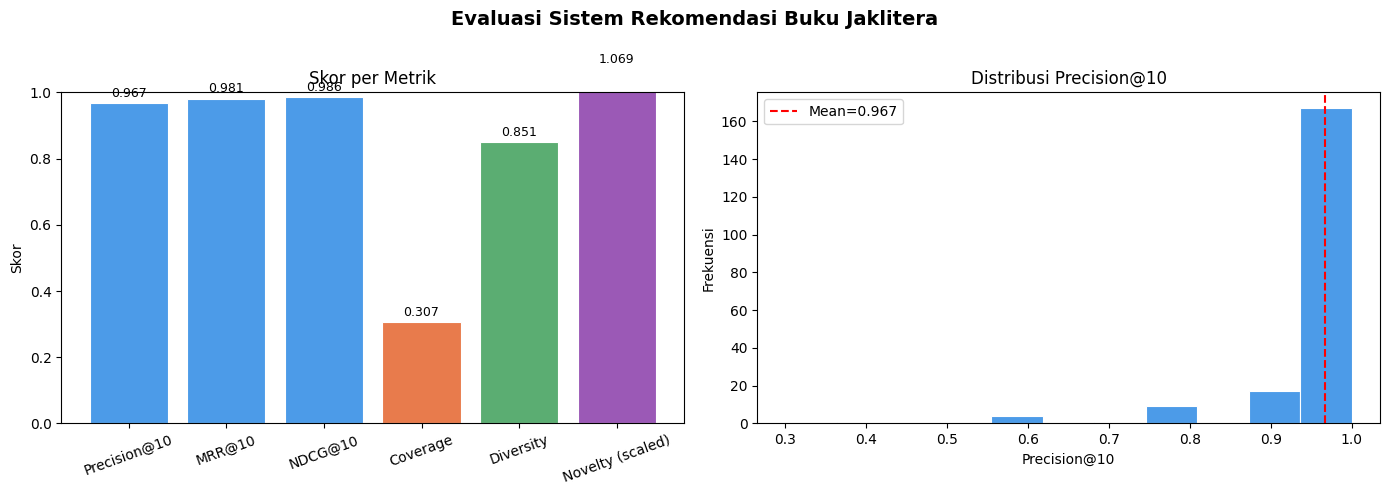

💾 Plot disimpan: evaluasi_rekomendasi.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

metrics = {
    f'Precision@{TOP_N}': np.mean(prec_scores),
    f'MRR@{TOP_N}'      : np.mean(mrr_scores),
    f'NDCG@{TOP_N}'     : np.mean(ndcg_scores),
    'Coverage'          : cov,
    'Diversity'         : np.mean(div_scores),
    'Novelty (scaled)'  : nov / 10   # skala ke 0-1 agar sebanding
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Sistem Rekomendasi Buku Jaklitera', fontsize=14, fontweight='bold')

# Bar chart
ax1 = axes[0]
colors = ['#4C9BE8', '#4C9BE8', '#4C9BE8', '#E87B4C', '#5BAD72', '#9B59B6']
bars   = ax1.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white', linewidth=0.8)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Skor')
ax1.set_title('Skor per Metrik')
ax1.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, metrics.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Distribusi Precision@K
ax2 = axes[1]
ax2.hist(prec_scores, bins=11, color='#4C9BE8', edgecolor='white', linewidth=0.8)
ax2.axvline(np.mean(prec_scores), color='red', linestyle='--', label=f'Mean={np.mean(prec_scores):.3f}')
ax2.set_xlabel(f'Precision@{TOP_N}')
ax2.set_ylabel('Frekuensi')
ax2.set_title(f'Distribusi Precision@{TOP_N}')
ax2.legend()

plt.tight_layout()
plt.savefig('evaluasi_rekomendasi.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Plot disimpan: evaluasi_rekomendasi.png')

## 10. Analisis Sensitivitas Bobot

In [13]:
from itertools import product as iproduct

def evaluate_weights(wj, wd, wp, wk, sample=100):
    """Evaluasi Precision@K untuk kombinasi bobot tertentu."""
    np.random.seed(0)
    idx_sample = np.random.choice(df.index, sample, replace=False)
    scores = []
    for idx in idx_sample:
        sim_j = cosine_similarity(mat_judul[idx],    mat_judul).flatten()
        sim_d = cosine_similarity(mat_desc[idx],     mat_desc).flatten()
        sim_p = cosine_similarity(mat_penulis[idx],  mat_penulis).flatten()
        sim_k = cosine_similarity(mat_kategori[idx], mat_kategori).flatten()
        hybrid   = wj*sim_j + wd*sim_d + wp*sim_p + wk*sim_k
        sorted_i = np.argsort(hybrid)[::-1]
        recs     = [i for i in sorted_i if i != idx][:TOP_N]
        q_cat    = df.loc[idx, 'Kategori_Asal']
        prec     = sum(1 for r in recs if df.loc[r, 'Kategori_Asal'] == q_cat) / TOP_N
        scores.append(prec)
    return np.mean(scores)

# Grid search sederhana (bobot judul dan deskripsi)
results_grid = []
for wj in [0.3, 0.4, 0.5, 0.6]:
    for wd in [0.2, 0.3, 0.4]:
        wp = 0.15
        wk = max(0.0, 1.0 - wj - wd - wp)
        if wk < 0:
            continue
        p = evaluate_weights(wj, wd, wp, wk, sample=80)
        results_grid.append({'w_judul': wj, 'w_desc': wd, 'w_penulis': wp,
                              'w_kategori': round(wk,2), 'precision': round(p,4)})

grid_df = pd.DataFrame(results_grid).sort_values('precision', ascending=False)
print('Top 5 kombinasi bobot:')
print(grid_df.head())

Top 5 kombinasi bobot:
   w_judul  w_desc  w_penulis  w_kategori  precision
0      0.3     0.2       0.15        0.35     0.9925
1      0.3     0.3       0.15        0.25     0.9875
2      0.3     0.4       0.15        0.15     0.9875
3      0.4     0.2       0.15        0.25     0.9862
4      0.4     0.3       0.15        0.15     0.9850


## 11. Interactive Lookup

In [ ]:
# ─── Jalankan sel ini untuk mencoba rekomendasi buku apapun ─────────────────
judul_cari = "laut bercerita"
n_rec      = int(input('Berapa rekomendasi? [default 10]: ') or '10')

hasil_input = recommend(judul_cari, top_n=n_rec)
if not hasil_input.empty:
    display(hasil_input)